# Implied vol of a TWAP-settled Up/Down market

`analysis/twap_iv.py` gives the fair probability of *Up* for a market that settles on the 60 s
Chainlink TWAP, and inverts it for the volatility the market is implying.

**Model.** Log price is a driftless Brownian motion with per-second vol $\sigma$. The settlement
TWAP is the equal-weighted mean of the last $m$ one-second prices of the window. At a time with
$n$ seconds left, $k$ of the $m$ samples are already published and $r = m-k$ are still in the
future at offsets $\tau_1<\dots<\tau_r$ from now. With $A$ the final log-TWAP,

$$E[A] = \frac{1}{m}\Big(\sum_{\text{obs}} \ln x_i + r\ln S_{\text{now}}\Big), \qquad
\mathrm{Var}[A] = \sigma^2 c^2, \quad c^2 = \frac{1}{m^2}\sum_{i,j}\min(\tau_i,\tau_j)$$

$$P(\text{Up}) = \Phi\!\left(\frac{d}{\sigma c}\right), \qquad d = E[A] - \ln K$$

The binary price depends on $\sigma$ only through $d/\sigma$, so the implied vol is closed form:

$$\sigma_{\text{impl}} = \frac{d}{c\,\Phi^{-1}(p_{\text{Up}})}$$

It exists only when the market and the running average agree on direction — a symmetric model
cannot say "Up is more likely" while the expected TWAP sits below the line. Those trades return NaN.

Nothing is BTC-specific: the same function prices ETH / SOL / any TWAP-settled market once you
hand it the reference, the latest price, the published TWAP samples and the seconds left.

In [1]:
import sys, os
sys.path.insert(0, "/home/joshua/btc"); os.chdir("/home/joshua/btc")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from datetime import datetime, timezone, timedelta
from analysis.twap_iv import TwapState, prob_up, implied_vol, implied_vol_series, annualise, per_sec
from data_collection.load import load_klines

C = {"blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "grey": "#52514e", "grid": "#e6e5e1"}
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.color": C["grid"], "axes.titlelocation": "left", "legend.frameon": False, "figure.dpi": 110})

## 1. The function on a hand-made state

In [2]:
# 40 s left in a 60-sample TWAP: 20 samples published (all 99.98), price now 100.03, reference 100
st = TwapState(ref=100.0, spot=100.03, seconds_left=40, twap_window=60, observed=[99.98] * 20)
print(f"expected final TWAP is {st.d()*1e4:+.2f} bp above the reference;  c = {np.sqrt(st.variance_factor()):.2f} s^0.5")
for ann in (0.20, 0.40, 0.80):
    print(f"  sigma = {ann:.0%} annualised  ->  P(Up) = {prob_up(st, per_sec(ann)):.3f}")
p = prob_up(st, per_sec(0.40))
print(f"invert P(Up) = {p:.3f}  ->  implied vol = {annualise(implied_vol(st, p)):.1%}  (round trip)")
print("market says 0.70 but the running TWAP is below the line ->", implied_vol(TwapState(100, 99.9, 120), 0.70))

expected final TWAP is +1.33 bp above the reference;  c = 2.48 s^0.5
  sigma = 20% annualised  ->  P(Up) = 0.934
  sigma = 40% annualised  ->  P(Up) = 0.775
  sigma = 80% annualised  ->  P(Up) = 0.647
invert P(Up) = 0.775  ->  implied vol = 40.0%  (round trip)
market says 0.70 but the running TWAP is below the line -> nan


How much of the settlement is still uncertain, as a function of time left? $c$ is the standard
deviation of the final log-TWAP per unit of per-second vol. Before the TWAP window opens it grows
like $\sqrt{n - m + (m+1)(2m+1)/6m}$ (the $N_{\text{eff}}\approx 260$ of a 300 s window); inside it,
it collapses like $n^{3/2}$.

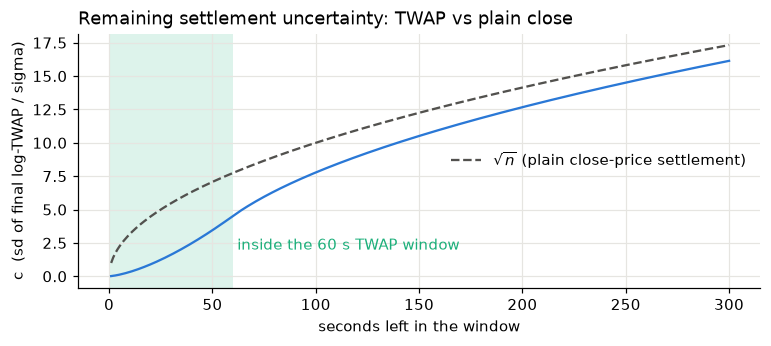

In [3]:
n = np.arange(1, 301)
c = np.array([np.sqrt(TwapState(1, 1, s).variance_factor()) for s in n])
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(n, c, color=C["blue"]); ax.plot(n, np.sqrt(n), color=C["grey"], ls="--", label=r"$\sqrt{n}$ (plain close-price settlement)")
ax.axvspan(0, 60, color=C["aqua"], alpha=0.15, lw=0); ax.text(62, 2, "inside the 60 s TWAP window", color=C["aqua"])
ax.set_xlabel("seconds left in the window"); ax.set_ylabel("c  (sd of final log-TWAP / sigma)"); ax.legend()
ax.set_title("Remaining settlement uncertainty: TWAP vs plain close"); plt.show()

## 2. Real markets: Polymarket BTC 5-minute Up/Down, 2026-08-15/16

Trades of the *Up* token from the CLOB capture in `data/polymarket/`, priced against the Binance
USDT-M perp (last aggTrade price each second, from the daily archive in `data/raw/aggtrades/`) as
the proxy for the Chainlink series. The USD/USDT basis cancels because reference and spot come
from the same series; the ~2 s Chainlink lag, the venue mix and the ~0.5 bp of basis *noise* do
not — so the proxy is only informative in windows where BTC actually moved. These dates are after
the 2026-08-14 switch to the 60 s TWAP, so `twap_window = 60`.

In [4]:
markets = pd.read_parquet("data/polymarket/btc-updown-5m/markets.parquet")
markets = markets[markets.has_live_window_data == 1].copy()
markets["window_start"] = pd.to_datetime(markets.window_start, unit="s", utc=True)
markets["window_end"] = pd.to_datetime(markets.window_end, unit="s", utc=True)

days = ["2026-08-15", "2026-08-16"]
trades = pd.concat([pd.read_parquet(f"data/polymarket/btc-updown-5m/trades/window_date={d}/data.parquet") for d in days])
trades = trades[(trades.outcome == "Up") & (trades.in_window == 1)].copy()
trades["price_prob"] = trades.price_prob.astype(float)

agg = pd.concat([pd.read_csv(f"data/raw/aggtrades/BTCUSDT-perp-aggTrades-{d}.zip", usecols=["price", "transact_time"]) for d in days])
agg.index = pd.to_datetime(agg.transact_time, unit="ms", utc=True)
px = agg.price.resample("1s").last().ffill()                 # perp last-trade price, one per second
r1 = np.log(px).diff()
rv30 = (r1.pow(2).rolling(1800).mean() ** 0.5).rename("rv30")      # trailing 30-min realised vol, per second
print(f"{trades.slug.nunique()} markets, {len(trades):,} in-window Up trades, {len(px):,} price seconds")

575 markets, 702,494 in-window Up trades, 172,800 price seconds


### First, how much does BTC move inside a window here?

August 2026 was an unusually quiet regime (perp volume ~25–40k BTC/day, 1-min vol ≈ 1.5 bp,
~8 % annualised). Many 5-minute windows are decided by less than the ~0.5 bp of noise between
any Binance series and the Chainlink aggregate, and in those the proxy cannot say which way the
TWAP went — the market can, because it watches the actual feed. So the implied-vol analysis is
restricted to trades where the expected TWAP is at least 1 bp from the reference.

In [5]:
wins = markets[markets.window_start.dt.strftime("%Y-%m-%d").isin(days)]
move = []
for ws, we in zip(wins.window_start, wins.window_end):
    ref = px[ws - pd.Timedelta(seconds=60): ws - pd.Timedelta(seconds=1)].mean()
    close = px[we - pd.Timedelta(seconds=59): we].mean()
    move.append((close / ref - 1) * 1e4)
move = pd.Series(move)
print(f"{len(move)} windows: |close TWAP - open TWAP| median {move.abs().median():.2f} bp, "
      f"p90 {move.abs().quantile(.9):.2f} bp;  {(move.abs() < 1).mean():.0%} of windows moved < 1 bp, "
      f"{(move.abs() < 0.5).mean():.0%} < 0.5 bp")

575 windows: |close TWAP - open TWAP| median 1.08 bp, p90 4.57 bp;  48% of windows moved < 1 bp, 32% < 0.5 bp


In [6]:
rows = []
for slug, g in trades.groupby("slug"):
    mk = markets[markets.slug == slug]
    if mk.empty:
        continue
    ws, we = mk.window_start.iloc[0], mk.window_end.iloc[0]
    out = implied_vol_series(g.sort_values("ts_exchange"), px, ws, we, twap_window=60)
    out["window_start"] = ws; out["rv30_ann"] = annualise(rv30[:ws].iloc[-1]); out["implied_winner"] = mk.implied_winner.iloc[0]
    rows.append(out)
iv_all = pd.concat(rows, ignore_index=True)
iv = iv_all[iv_all.d_bp.abs() >= 1].copy()
print(f"{len(iv_all):,} trades, {len(iv):,} with |d| >= 1 bp ({iv.slug.nunique()} windows). "
      f"Of those, implied vol is defined for {iv.iv_ann.notna().mean():.1%} "
      f"(the rest: market price on the other side of 0.5 from the expected TWAP)")

702,494 trades, 247,137 with |d| >= 1 bp (378 windows). Of those, implied vol is defined for 97.3% (the rest: market price on the other side of 0.5 from the expected TWAP)


### Three windows, second by second

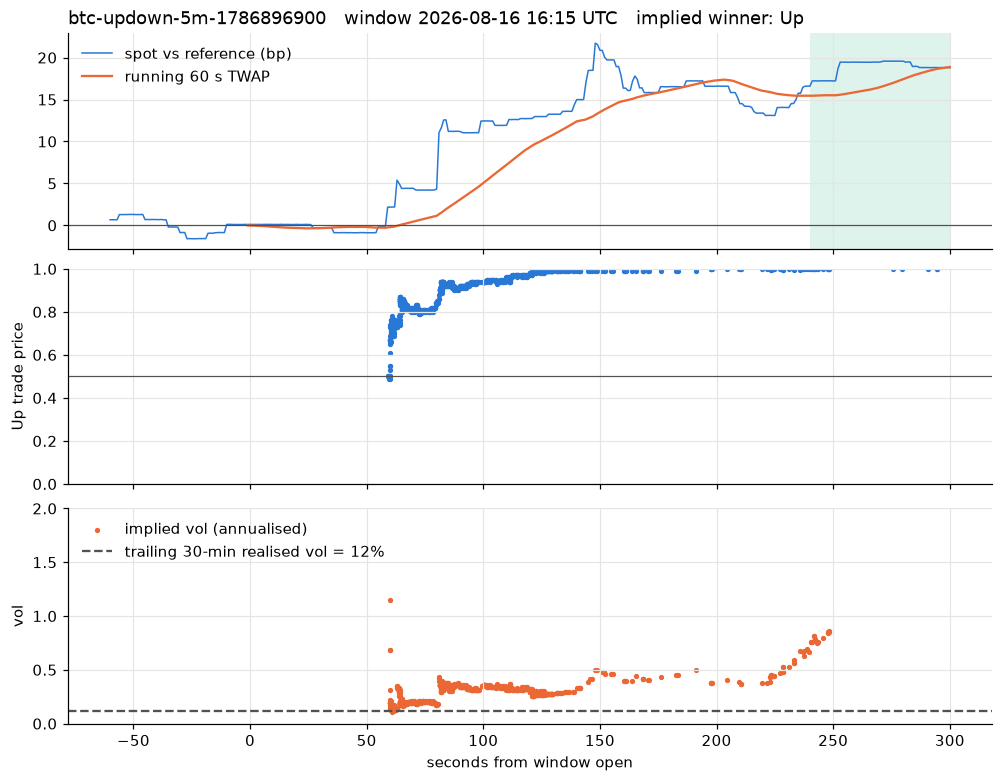

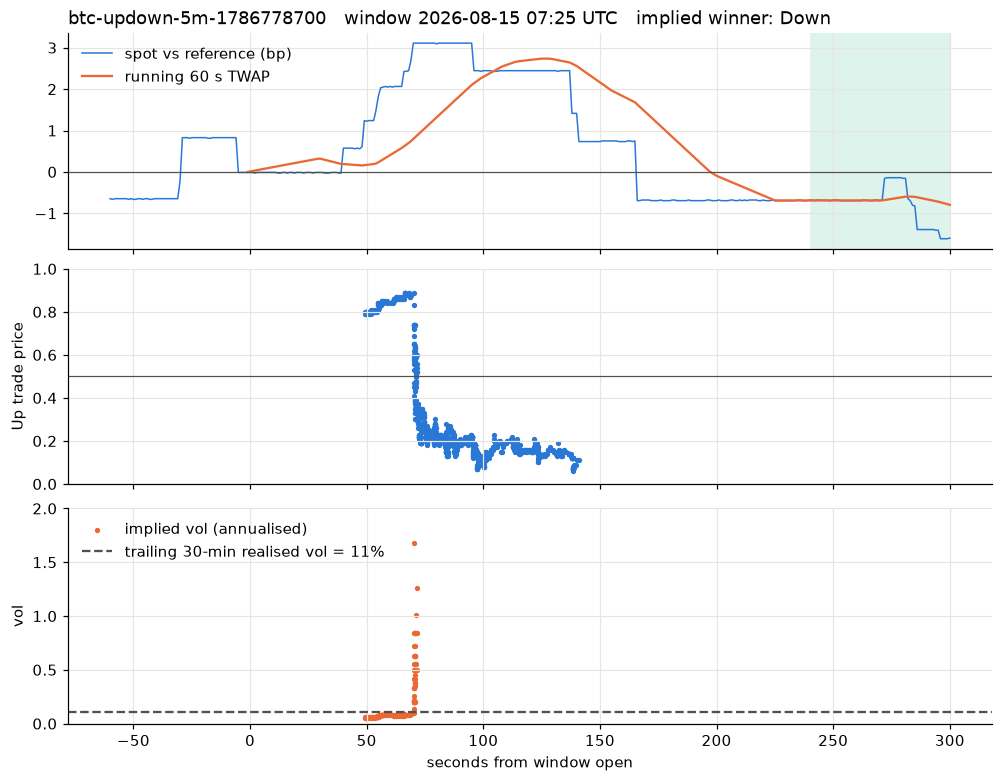

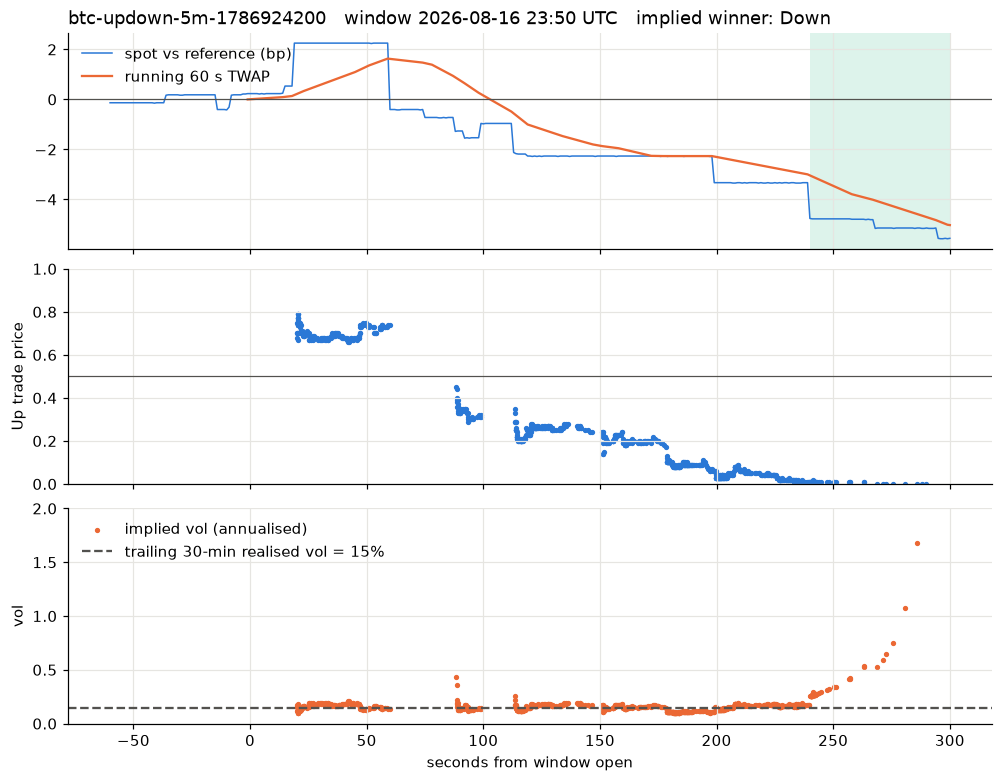

In [7]:
def show_window(slug):
    g = iv[iv.slug == slug].sort_values("ts_exchange"); ws = g.window_start.iloc[0]; we = ws + pd.Timedelta(minutes=5)
    p = px[ws - pd.Timedelta(seconds=60): we]
    ref = px[ws - pd.Timedelta(seconds=60): ws - pd.Timedelta(seconds=1)].mean()
    t = (p.index - ws).total_seconds(); tt = (g.ts_exchange - ws).dt.total_seconds()
    fig, ax = plt.subplots(3, 1, figsize=(9, 7), sharex=True, constrained_layout=True)
    ax[0].plot(t, (p / ref - 1) * 1e4, color=C["blue"], lw=1, label="spot vs reference (bp)")
    tw = p.rolling(60).mean(); ax[0].plot(t, (tw / ref - 1) * 1e4, color=C["orange"], lw=1.5, label="running 60 s TWAP")
    ax[0].axhline(0, color=C["grey"], lw=0.8); ax[0].axvspan(240, 300, color=C["aqua"], alpha=0.15, lw=0); ax[0].legend(loc="upper left")
    ax[0].set_title(f"{slug}   window {ws:%Y-%m-%d %H:%M} UTC   implied winner: {g.implied_winner.iloc[0]}")
    ax[1].scatter(tt, g.p_up, s=6, color=C["blue"]); ax[1].set_ylim(0, 1); ax[1].set_ylabel("Up trade price"); ax[1].axhline(0.5, color=C["grey"], lw=0.8)
    ax[2].scatter(tt, g.iv_ann, s=6, color=C["orange"], label="implied vol (annualised)")
    ax[2].axhline(g.rv30_ann.iloc[0], color=C["grey"], ls="--", label=f"trailing 30-min realised vol = {g.rv30_ann.iloc[0]:.0%}")
    ax[2].set_ylim(0, 2); ax[2].set_ylabel("vol"); ax[2].set_xlabel("seconds from window open"); ax[2].legend(loc="upper left")
    plt.show()

# the biggest move, a window where the market disagreed with the running TWAP the most, and a mid-sized one
per = iv_all.groupby("slug").agg(n=("iv_ann", "size"), frac_def=("iv_ann", lambda x: x.notna().mean()),
                                 d_end=("d_bp", "last"), d_max=("d_bp", lambda x: x.abs().max()))
per = per[(per.n > 150) & (per.d_max > 3)]
for slug in [per.d_end.abs().idxmax(), per.frac_def.idxmin(), (per.d_end.abs() - 5).abs().idxmin()]:
    show_window(slug)

### What vol does the market imply, and when?

Pooled over both days, by time remaining. Compare to the trailing 30-minute realised vol at each
window's open (median across windows shown as the dashed line).

            trades  defined  iv_p25  iv_median  iv_p75  rv30_median
left_bin                                                           
(0, 30]       3791    0.973   0.286      0.463   1.096        0.057
(30, 60]     24164    0.970   0.113      0.154   0.211        0.067
(60, 120]    63609    0.988   0.079      0.108   0.158        0.071
(120, 180]   57494    0.980   0.072      0.100   0.155        0.071
(180, 240]   52630    0.944   0.073      0.102   0.159        0.069
(240, 300]   45449    0.980   0.080      0.113   0.181        0.076


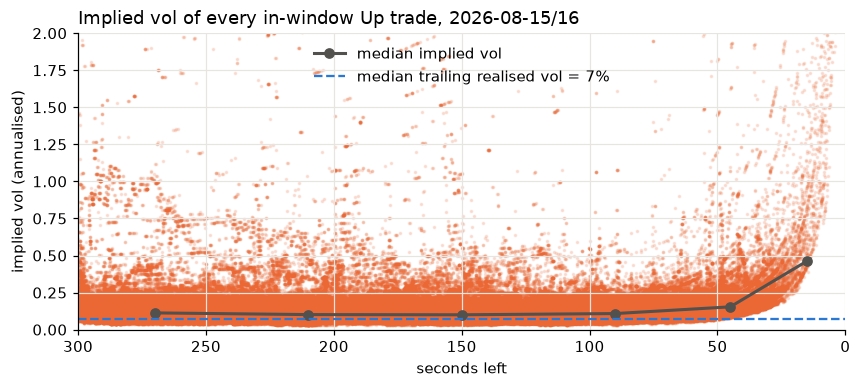

In [8]:
bins = [0, 30, 60, 120, 180, 240, 300]
iv["left_bin"] = pd.cut(iv.seconds_left, bins, right=True)
tab = iv.groupby("left_bin", observed=True).agg(trades=("iv_ann", "size"), defined=("iv_ann", lambda x: x.notna().mean()),
                                               iv_p25=("iv_ann", lambda x: x.quantile(.25)), iv_median=("iv_ann", "median"),
                                               iv_p75=("iv_ann", lambda x: x.quantile(.75)))
tab["rv30_median"] = iv.groupby("left_bin", observed=True).rv30_ann.median()
print(tab.round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 3.5))
d = iv[iv.iv_ann.notna() & (iv.iv_ann < 3)]
ax.scatter(d.seconds_left, d.iv_ann, s=2, alpha=0.15, color=C["orange"])
ax.plot(tab.index.map(lambda b: b.mid), tab.iv_median, color=C["grey"], lw=2, marker="o", label="median implied vol")
ax.axhline(iv.rv30_ann.median(), color=C["blue"], ls="--", label=f"median trailing realised vol = {iv.rv30_ann.median():.0%}")
ax.set_xlim(300, 0); ax.set_ylim(0, 2); ax.set_xlabel("seconds left"); ax.set_ylabel("implied vol (annualised)")
ax.set_title("Implied vol of every in-window Up trade, 2026-08-15/16"); ax.legend(); plt.show()

### Reading it

* **Implied vol is only meaningful when the outcome is in doubt.** Near the end of a window most
  trades sit at 0.95+ with the TWAP far from the line; there $\sigma_{\text{impl}}$ is a ratio of
  two small numbers and the scatter explodes. The informative region is the first 2–4 minutes.
* **A large "undefined" share is itself a finding**: the market is pricing Up above 0.5 while the
  expected TWAP is below the reference (or vice versa). Under a symmetric model that is a mispricing
  of *direction*, not of vol — the stale-reference effect: the market has not fully priced the 30 s
  lag between spot and the TWAP. Part of it is also the proxy (Binance perp vs the actual Chainlink
  series), which is why trades with |d| < 1 bp are excluded — there the proxy's sign is noise.
* **The regime matters.** In this sample BTC barely moves, so the market's implied vol is measured
  against very small $d$; on a normal-vol day the same code gives much cleaner numbers.
* **Where it is defined, compare the implied level to realised.** A market implying much more vol
  than trailing realised is paying too little for the side the running TWAP favours; much less,
  too much. The bucket table above is the summary; the per-window plots show the dynamics.

## 3. Using it live

```python
from analysis.twap_iv import TwapState, prob_up, implied_vol, per_sec

state = TwapState(ref=open_twap,            # the Chainlink TWAP report at the window open
                  spot=latest_chainlink,     # latest per-second Chainlink price (or Binance adjusted for basis)
                  seconds_left=window_end - now,
                  twap_window=60,
                  observed=twap_samples_so_far)   # per-second Chainlink prices inside the final 60 s

fair = prob_up(state, per_sec(sigma_ann_from_trailing_rv))   # what you think it's worth
sigma_mkt = implied_vol(state, best_ask_up)                    # what the book is implying
```

For a different asset, only the inputs change. The model's known blind spots — fat tails
(Student-t innovations, roughly $\nu\approx4$–5), vol clustering (use a 15–30 min trailing
realised vol, floored), and the ~2 s Chainlink lag — are all in the *inputs* to this function,
not in the function.